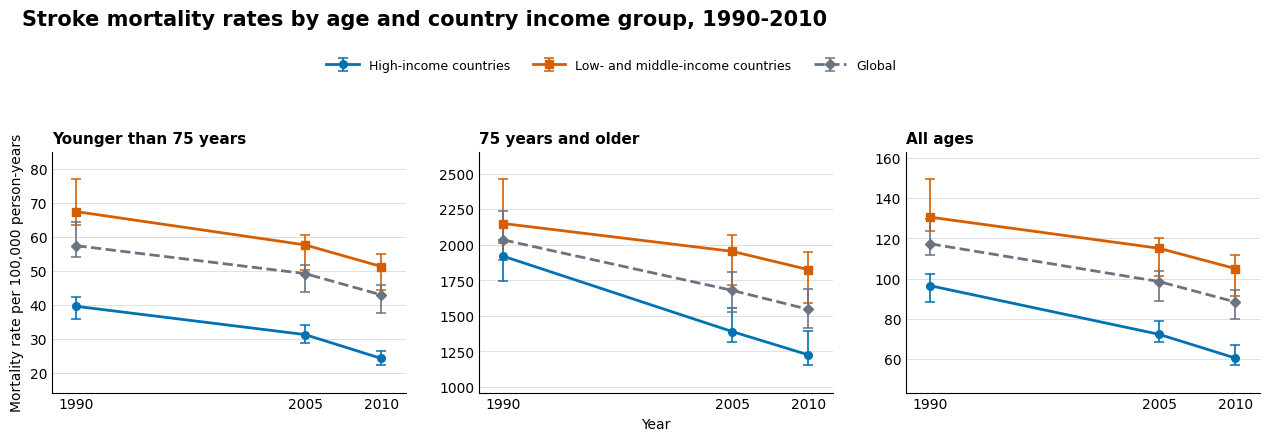

In [13]:
import matplotlib.pyplot as plt
import pandas as pd
df = pd.read_csv("feigin2014_table1_mortality.csv")

plt.rcParams.update(
    {
        "font.family": "DejaVu Sans",
        "font.size": 10,
        "axes.titlesize": 11,
        "axes.labelsize": 10,
        "legend.fontsize": 9,
    }
)


age_order = ["<75", ">=75", "all"]
age_labels = {
    "<75": "Younger than 75 years",
    ">=75": "75 years and older",
    "all": "All ages",
}

group_order = ["high", "low_and_middle", "all"]
group_labels = {
    "high": "High-income countries",
    "low_and_middle": "Low- and middle-income countries",
    "all": "Global",
}

styles = {
    "high": {"color": "#0072B2", "marker": "o", "linestyle": "-"},
    "low_and_middle": {"color": "#D55E00", "marker": "s", "linestyle": "-"},
    "all": {"color": "#6B7280", "marker": "D", "linestyle": "--"},
}


fig, axes = plt.subplots(1, 3, figsize=(13.4, 4.8), sharex=True)


for ax, age in zip(axes, age_order):
    panel = df[df["age_group"] == age]

    for group in group_order:
        z = panel[panel["income_group"] == group].sort_values("year")

        yerr = [
            z["mortality_rate"] - z["interval_low"],
            z["interval_high"] - z["mortality_rate"],
        ]

        ax.errorbar(
            z["year"],
            z["mortality_rate"],
            yerr=yerr,
            linewidth=2.0,
            markersize=5.5,
            capsize=3.5,
            capthick=1.1,
            elinewidth=1.2,
            label=group_labels[group],
            **styles[group]
        )

    ax.set_title(age_labels[age], loc="left", weight="bold")
    ax.set_xticks([1990, 2005, 2010])
    ax.grid(axis="y", color="#D1D5DB", linewidth=0.7, alpha=0.75)
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(axis="both", length=0)
    ax.margins(x=0.08, y=0.15)

axes[0].set_ylabel("Mortality rate per 100,000 person-years")
axes[1].set_xlabel("Year")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.91),
    ncol=3,
    frameon=False,
    handlelength=2.6,
    columnspacing=1.8,
)

fig.suptitle(
    "Stroke mortality rates by age and country income group, 1990-2010",
    x=0.06,
    y=0.99,
    ha="left",
    fontsize=15,
    weight="bold",
)

fig.tight_layout(rect=[0.04, 0.08, 0.995, 0.84], w_pad=2.4)

# Save figure and render in notebook
fig.savefig(
    "feigin_mortality_rates.png", dpi=300, bbox_inches="tight", facecolor="white"
)
plt.show()